# Chapter 4: Identification Spaces

**Source orientation:** Armstrong, *Basic Topology*, Chapter 4, printed pp. 65-86; PDF pp. 76-97. These pages were used for structure and terminology only. The prose, examples, code, and artifacts here are original to this notebook.

## Standalone Chapter Question

When a space is made by declaring several old points to be one new point, what topology is forced on the result, and which features survive the forgetting? Chapter 4 answers this with quotient maps, edge identifications, topological groups, and orbit spaces.

## Chapter Goal

By the end of the notebook you should be able to read a quotient construction in three interchangeable ways:

- as a partition of a source space into equivalence classes,
- as a projection map whose preimages decide openness,
- as a geometric model with invariants that can be checked after the drawing changes.

## Computational Translation Guide

| Book idea | Computational version used here | What we check |
| --- | --- | --- |
| Identification space | Equivalence classes plus a projection `q:X -> X/~` | endpoint or edge classes match the recipe |
| Quotient topology | A set downstairs is open exactly when its full preimage upstairs is open | neighborhoods near glued points must be saturated |
| Edge identifications | Boundary instructions on a rectangle, disk, or fundamental region | Euler characteristic, boundary count, orientability flag |
| Identification map | Onto map that carries exactly the quotient topology | compact-to-Hausdorff and open-map tests in examples |
| Topological group | A group whose multiplication and inversion respect topology | translations are homeomorphisms, quotient group examples are consistent |
| Orbit space | Points identified along a group action | representatives, stabilizers, and dense/closed orbit behavior |

## Visual Storyboard Logic

1. Start with the smallest quotient map, `[0,1] -> S^1`, and make the saturated-preimage rule visible.
2. Draw edge instructions for the cylinder, Mobius strip, torus, and a projective-plane style disk model, then attach invariant data to each model.
3. Build a theorem dependency graph for the chapter's proof tools: quotient continuity, identification maps, compact-Hausdorff tests, glueing, and attaching maps.
4. Treat `R/Z` and `Z^2` translations as topological-group quotient examples, with numerical group-operation checks.
5. Use an interactive Plotly orbit artifact to compare closed rational flow with dense irrational flow on the torus.
6. Finish with an applied lab that asks you to alter a fundamental-region recipe and predict which invariant should change.

## Library Routing

Matplotlib is used for static quotient diagrams because the point is incidence, edge orientation, and labeled neighborhoods. NetworkX is used for the proof-dependency graph. Plotly is used for the 3D quotient surface and orbit-space artifacts because rotation, zooming, and comparing representatives are essential to the geometry. Pandas records small invariant tables, and NumPy supplies numerical checks for maps, matrices, and sampled orbits.

In [1]:
from pathlib import Path
import sys
import json
import math

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

import networkx as nx
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def find_book_root(start: Path) -> Path:
    candidates = [start, start / "Basic-Topology", *start.parents]
    candidates.extend(parent / "Basic-Topology" for parent in start.parents)
    for candidate in candidates:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate.resolve()
    raise RuntimeError("Could not find Basic-Topology book root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html

UNIT = "chapter-04"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "html"
TABLE_DIR = ARTIFACT_ROOT / "tables"
CHECK_DIR = ARTIFACT_ROOT / "checks"
for directory in [FIG_DIR, HTML_DIR, TABLE_DIR, CHECK_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

artifact_registry = []
check_registry = []


def strip_trailing_whitespace(path: Path) -> Path:
    path = Path(path)
    text = path.read_text(encoding="utf-8")
    cleaned = "\n".join(line.rstrip() for line in text.splitlines())
    if text.endswith("\n"):
        cleaned += "\n"
    path.write_text(cleaned, encoding="utf-8")
    return path


def register(path: Path) -> Path:
    artifact_registry.append(Path(path))
    return Path(path)


BOOK_ROOT

WindowsPath('D:/Geometry/Basic-Topology')

## Quotient Maps: Topology By Preimage

A quotient map does two jobs at once. It forgets labels upstairs, and it tells the new space which subsets are open. The second job is the delicate one. A neighborhood of a glued point must lift to a full, saturated neighborhood of every representative upstairs.

The interval quotient `[0,1]/{0~1}` is the cleanest microscope. The two endpoints become one point on `S^1`. Around that point, a genuine neighborhood has two pieces upstairs, one near `0` and one near `1`. A single half-neighborhood near only one endpoint is not saturated, so it cannot be the full preimage of an open neighborhood downstairs.

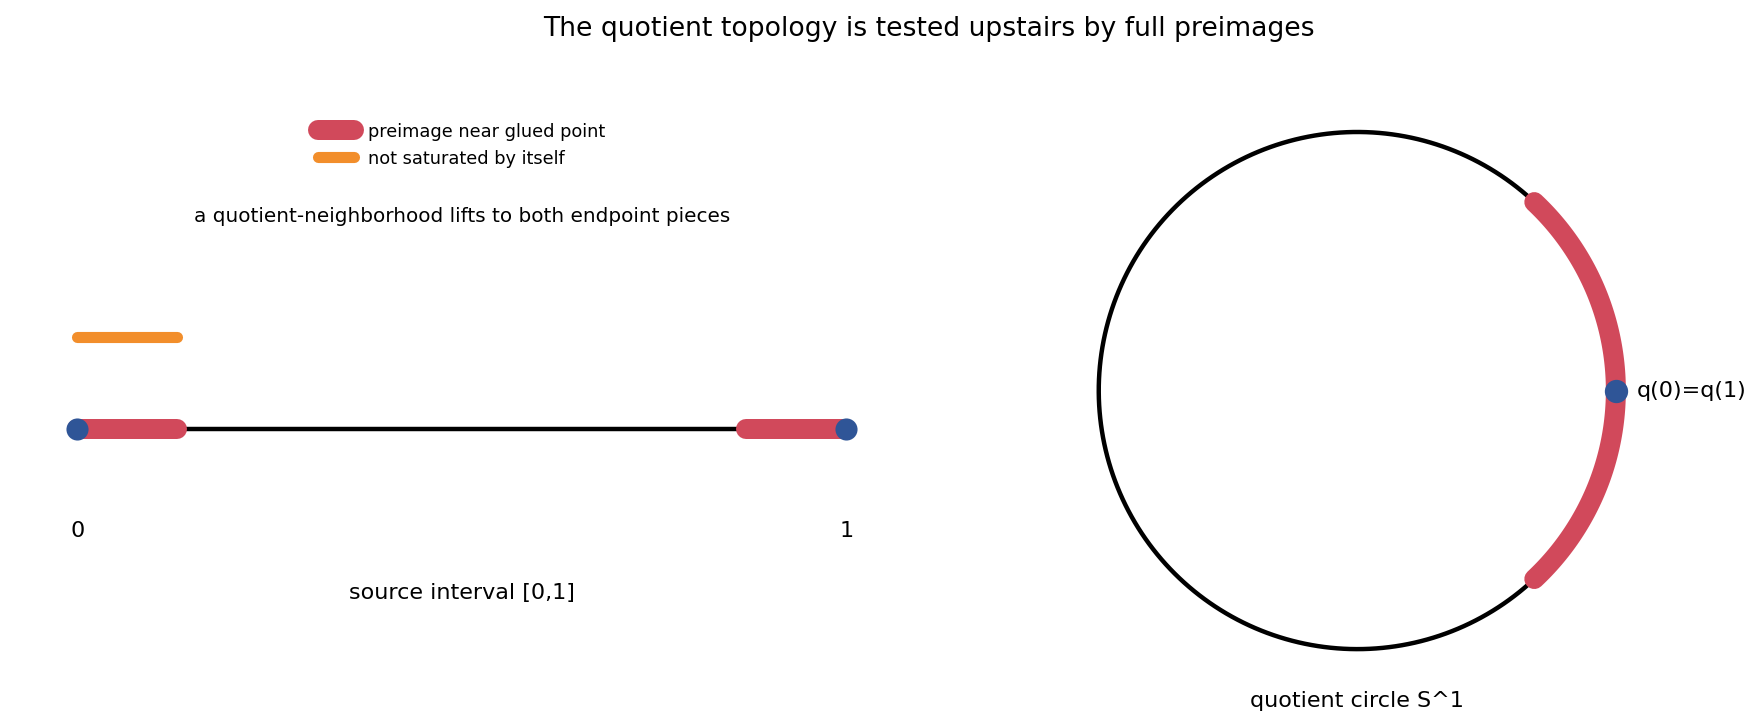

,concept,model,endpoint_identification_error,saturated_preimage_components,single_endpoint_piece_is_saturated,sample_arc_radius_min,sample_arc_radius_max
0,quotient topology via saturated preimages,"[0,1] with endpoints identified",2.449294e-16,"[[0.0, 0.13], [0.87, 1.0]]",False,1.0,1.0


In [2]:
def q_interval_to_circle(t):
    t = np.asarray(t, dtype=float)
    return np.column_stack([np.cos(2 * np.pi * t), np.sin(2 * np.pi * t)])


eps = 0.13
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
ax.plot([0, 1], [0, 0], color="black", lw=2)
ax.scatter([0, 1], [0, 0], s=80, color="#2f5597", zorder=5)
ax.plot([0, eps], [0, 0], color="#d1495b", lw=9, solid_capstyle="round", label="preimage near glued point")
ax.plot([1 - eps, 1], [0, 0], color="#d1495b", lw=9, solid_capstyle="round")
ax.plot([0, eps], [0.12, 0.12], color="#f28e2b", lw=5, solid_capstyle="round", label="not saturated by itself")
ax.text(0, -0.14, "0", ha="center")
ax.text(1, -0.14, "1", ha="center")
ax.text(0.5, -0.22, "source interval [0,1]", ha="center")
ax.text(0.5, 0.27, "a quotient-neighborhood lifts to both endpoint pieces", ha="center", fontsize=9)
ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-0.32, 0.42)
ax.set_aspect("equal")
ax.axis("off")
ax.legend(loc="upper center", frameon=False, fontsize=8)

ax = axes[1]
theta = np.linspace(0, 2 * np.pi, 500)
ax.plot(np.cos(theta), np.sin(theta), color="black", lw=2)
arc = np.linspace(-2 * np.pi * eps, 2 * np.pi * eps, 120)
ax.plot(np.cos(arc), np.sin(arc), color="#d1495b", lw=9, solid_capstyle="round")
ax.scatter([1], [0], s=90, color="#2f5597", zorder=5)
ax.text(1.08, 0, "q(0)=q(1)", va="center")
ax.text(0, -1.22, "quotient circle S^1", ha="center")
ax.set_aspect("equal")
ax.axis("off")
fig.suptitle("The quotient topology is tested upstairs by full preimages", y=1.02)
fig.tight_layout()

quotient_fig = register(save_matplotlib(fig, UNIT, "figures", "quotient-saturated-neighborhoods.png"))
plt.close(fig)

endpoint_error = float(np.linalg.norm(q_interval_to_circle([0])[0] - q_interval_to_circle([1])[0]))
near_endpoint_angles = np.concatenate([np.linspace(0, eps, 7), np.linspace(1 - eps, 1, 7)])
arc_points = q_interval_to_circle(near_endpoint_angles)
quotient_checks = {
    "concept": "quotient topology via saturated preimages",
    "model": "[0,1] with endpoints identified",
    "endpoint_identification_error": endpoint_error,
    "saturated_preimage_components": [[0.0, eps], [1.0 - eps, 1.0]],
    "single_endpoint_piece_is_saturated": False,
    "sample_arc_radius_min": float(np.min(np.linalg.norm(arc_points, axis=1))),
    "sample_arc_radius_max": float(np.max(np.linalg.norm(arc_points, axis=1))),
}
quotient_check_path = register(save_json(quotient_checks, UNIT, "checks", "quotient-map-checks.json"))
check_registry.append(quotient_check_path)

assert endpoint_error < 1e-12
assert abs(quotient_checks["sample_arc_radius_min"] - 1.0) < 1e-12
assert abs(quotient_checks["sample_arc_radius_max"] - 1.0) < 1e-12

display_artifact(quotient_fig, width=760)
pd.DataFrame([quotient_checks])

## Edge Identifications: Instructions Before Geometry

A rectangle drawing is not the quotient space yet. It is a source space plus boundary instructions. The invariant table below keeps that separation visible: the drawing can be stretched, subdivided, or embedded differently, while boundary components, orientability, and Euler characteristic remain meaningful checks.

The projective-plane style model is shown as a disk with antipodal boundary points identified. That is intentional: a faithful projective plane cannot sit in ordinary 3-space without singular behavior, so the quotient instruction is the primary object.

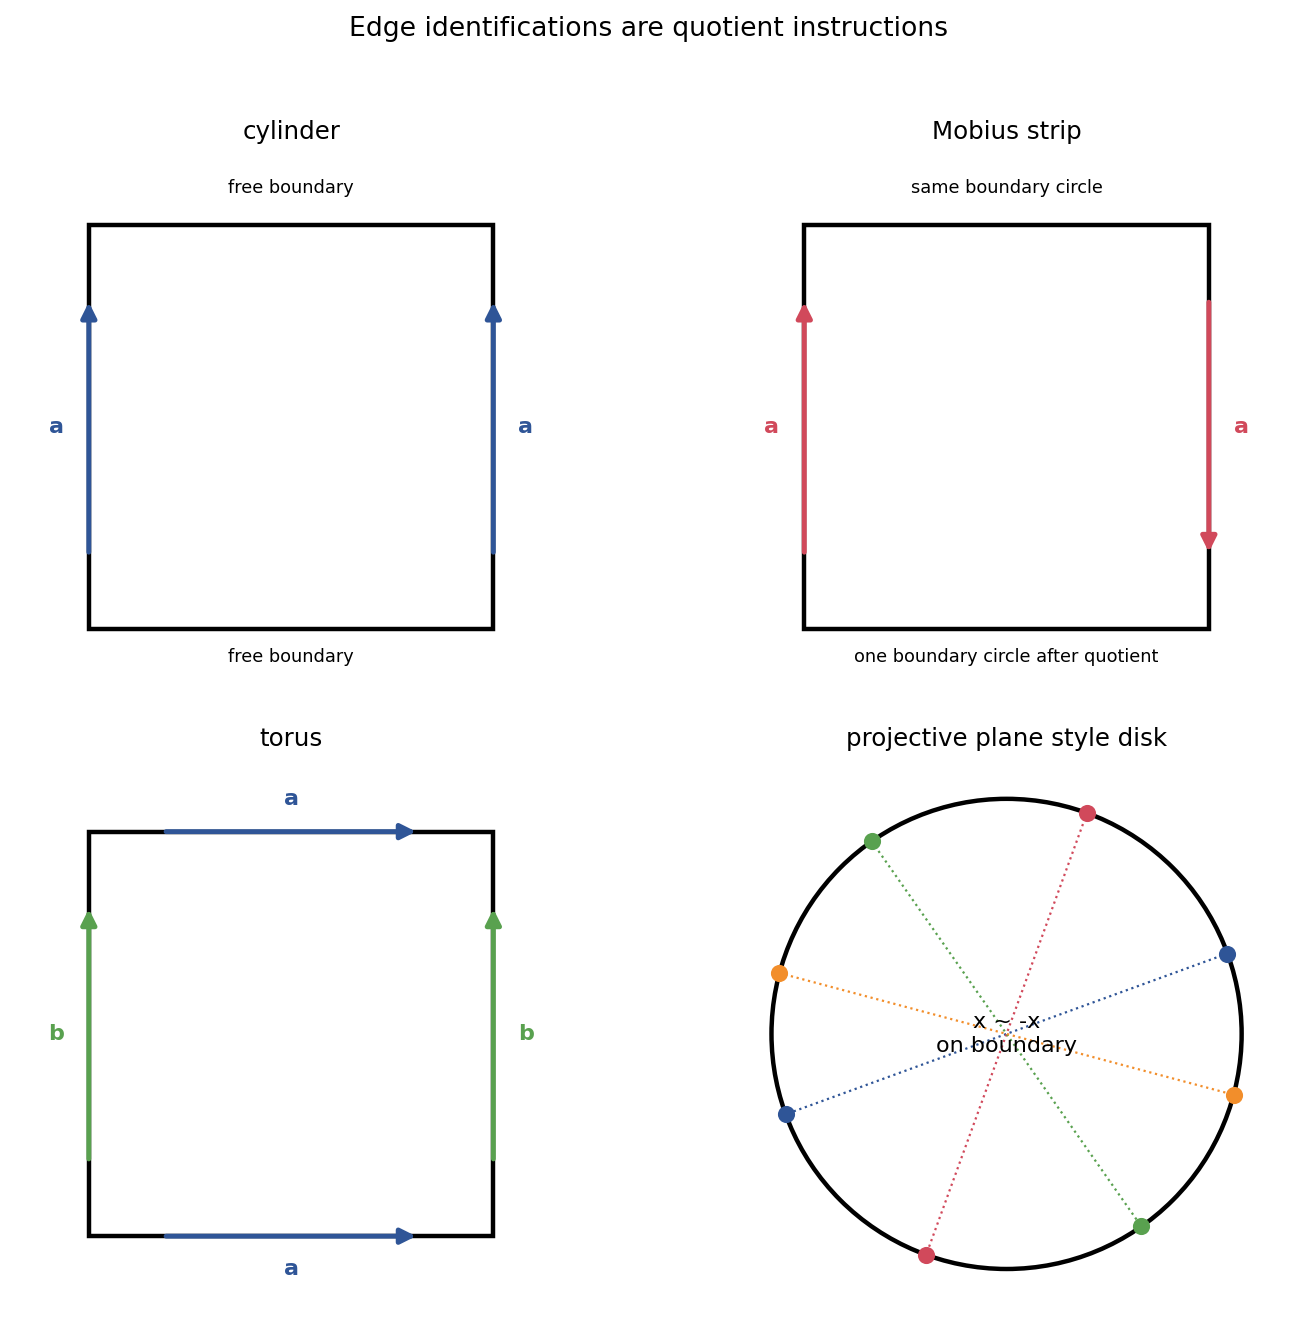

,model,recipe,boundary_components,orientable,euler_characteristic,local_seam_test
0,cylinder,identify one opposite edge pair with matching ...,2,True,0,two ordinary half-neighborhoods meet without a...
1,Mobius strip,identify one opposite edge pair with reversed ...,1,False,0,"the seam is locally ordinary, but a transverse..."
2,torus,identify both opposite edge pairs with matchin...,0,True,0,each edge neighborhood is paired with its oppo...
3,projective plane style disk,identify every boundary point of a disk with i...,0,False,1,boundary pairs become ordinary surface neighbo...


In [3]:
edge_models = [
    {
        "model": "cylinder",
        "recipe": "identify one opposite edge pair with matching direction",
        "boundary_components": 2,
        "orientable": True,
        "euler_characteristic": 0,
        "local_seam_test": "two ordinary half-neighborhoods meet without a twist",
    },
    {
        "model": "Mobius strip",
        "recipe": "identify one opposite edge pair with reversed direction",
        "boundary_components": 1,
        "orientable": False,
        "euler_characteristic": 0,
        "local_seam_test": "the seam is locally ordinary, but a transverse arrow returns reversed",
    },
    {
        "model": "torus",
        "recipe": "identify both opposite edge pairs with matching directions",
        "boundary_components": 0,
        "orientable": True,
        "euler_characteristic": 0,
        "local_seam_test": "each edge neighborhood is paired with its opposite mate",
    },
    {
        "model": "projective plane style disk",
        "recipe": "identify every boundary point of a disk with its antipode",
        "boundary_components": 0,
        "orientable": False,
        "euler_characteristic": 1,
        "local_seam_test": "boundary pairs become ordinary surface neighborhoods after quotienting",
    },
]
edge_df = pd.DataFrame(edge_models)
edge_table_path = register(TABLE_DIR / "edge-model-invariants.csv")
edge_df.to_csv(edge_table_path, index=False)


def arrow(ax, start, end, color, text=None, text_xy=None):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14, lw=2.2, color=color))
    if text:
        x, y = text_xy if text_xy else ((start[0] + end[0]) / 2, (start[1] + end[1]) / 2)
        ax.text(x, y, text, color=color, ha="center", va="center", fontsize=10, weight="bold")


def base_square(ax, title):
    ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, lw=2, color="black"))
    ax.set_xlim(-0.18, 1.18)
    ax.set_ylim(-0.18, 1.18)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=11)


fig, axes = plt.subplots(2, 2, figsize=(9.5, 8.4))
axes = axes.ravel()

base_square(axes[0], "cylinder")
arrow(axes[0], (0, 0.18), (0, 0.82), "#2f5597", "a", (-0.08, 0.5))
arrow(axes[0], (1, 0.18), (1, 0.82), "#2f5597", "a", (1.08, 0.5))
axes[0].text(0.5, -0.08, "free boundary", ha="center", fontsize=8)
axes[0].text(0.5, 1.08, "free boundary", ha="center", fontsize=8)

base_square(axes[1], "Mobius strip")
arrow(axes[1], (0, 0.18), (0, 0.82), "#d1495b", "a", (-0.08, 0.5))
arrow(axes[1], (1, 0.82), (1, 0.18), "#d1495b", "a", (1.08, 0.5))
axes[1].text(0.5, -0.08, "one boundary circle after quotient", ha="center", fontsize=8)
axes[1].text(0.5, 1.08, "same boundary circle", ha="center", fontsize=8)

base_square(axes[2], "torus")
arrow(axes[2], (0.18, 0), (0.82, 0), "#2f5597", "a", (0.5, -0.08))
arrow(axes[2], (0.18, 1), (0.82, 1), "#2f5597", "a", (0.5, 1.08))
arrow(axes[2], (0, 0.18), (0, 0.82), "#59a14f", "b", (-0.08, 0.5))
arrow(axes[2], (1, 0.18), (1, 0.82), "#59a14f", "b", (1.08, 0.5))

ax = axes[3]
ax.add_patch(Circle((0.5, 0.5), 0.47, fill=False, lw=2, color="black"))
colors = ["#2f5597", "#d1495b", "#59a14f", "#f28e2b"]
angles = [20, 70, 125, 165]
for color, angle in zip(colors, angles):
    rad = math.radians(angle)
    x1, y1 = 0.5 + 0.47 * math.cos(rad), 0.5 + 0.47 * math.sin(rad)
    x2, y2 = 0.5 - 0.47 * math.cos(rad), 0.5 - 0.47 * math.sin(rad)
    ax.scatter([x1, x2], [y1, y2], s=45, color=color, zorder=5)
    ax.plot([x1, x2], [y1, y2], color=color, lw=1, ls=":")
ax.text(0.5, 0.5, "x ~ -x\non boundary", ha="center", va="center", fontsize=10)
ax.set_title("projective plane style disk", fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.axis("off")

fig.suptitle("Edge identifications are quotient instructions", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
edge_gallery_path = register(save_matplotlib(fig, UNIT, "figures", "edge-identification-gallery.png"))
plt.close(fig)

edge_checks = {
    "concept": "edge identification models and quotient invariants",
    "models": edge_df.to_dict(orient="records"),
    "euler_characteristics": dict(zip(edge_df["model"], edge_df["euler_characteristic"])),
    "nonorientable_models": edge_df.loc[~edge_df["orientable"], "model"].tolist(),
    "closed_models": edge_df.loc[edge_df["boundary_components"] == 0, "model"].tolist(),
}
edge_check_path = register(save_json(edge_checks, UNIT, "checks", "edge-model-checks.json"))
check_registry.append(edge_check_path)

assert edge_checks["euler_characteristics"]["torus"] == 0
assert edge_checks["euler_characteristics"]["projective plane style disk"] == 1
assert set(edge_checks["nonorientable_models"]) == {"Mobius strip", "projective plane style disk"}

display_artifact(edge_gallery_path, width=760)
edge_df

## Embedded Models And Parameter Checks

The quotient construction of a surface is abstract, but parameterized models can still help inspect local behavior. The cylinder and torus close with matching parameters. The Mobius strip closes only after the transverse coordinate is reversed. That reversal is the half-twist, and the code checks it numerically.

In [4]:
def cylinder_xyz(u, v, radius=1.0, height=1.4):
    return radius * np.cos(u), radius * np.sin(u), height * (v - 0.5)


def mobius_xyz(u, v, radius=1.35):
    return (
        (radius + v * np.cos(u / 2)) * np.cos(u),
        (radius + v * np.cos(u / 2)) * np.sin(u),
        v * np.sin(u / 2),
    )


def torus_xyz(u, v, major=1.55, minor=0.42):
    return (
        (major + minor * np.cos(v)) * np.cos(u),
        (major + minor * np.cos(v)) * np.sin(u),
        minor * np.sin(v),
    )


u = np.linspace(0, 2 * np.pi, 90)
v_cyl = np.linspace(0, 1, 32)
v_mob = np.linspace(-0.35, 0.35, 32)
v_tor = np.linspace(0, 2 * np.pi, 70)
U_c, V_c = np.meshgrid(u, v_cyl)
U_m, V_m = np.meshgrid(u, v_mob)
U_t, V_t = np.meshgrid(u, v_tor)

Xc, Yc, Zc = cylinder_xyz(U_c, V_c)
Xm, Ym, Zm = mobius_xyz(U_m, V_m)
Xt, Yt, Zt = torus_xyz(U_t, V_t)

surface_fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "scene"}, {"type": "scene"}, {"type": "scene"}]],
    subplot_titles=["cylinder: same edge direction", "Mobius: reversed seam", "torus: two periodic directions"],
)
surface_style = dict(colorscale="Viridis", showscale=False, opacity=0.95)
surface_fig.add_trace(go.Surface(x=Xc, y=Yc, z=Zc, **surface_style), row=1, col=1)
surface_fig.add_trace(go.Surface(x=Xm, y=Ym, z=Zm, **surface_style), row=1, col=2)
surface_fig.add_trace(go.Surface(x=Xt, y=Yt, z=Zt, **surface_style), row=1, col=3)
for i in range(1, 4):
    surface_fig.update_scenes(
        row=1,
        col=i,
        aspectmode="data",
        xaxis_visible=False,
        yaxis_visible=False,
        zaxis_visible=False,
    )
surface_fig.update_layout(
    title="Interactive quotient surface models: rotate to inspect seams",
    height=520,
    margin=dict(l=0, r=0, t=70, b=0),
)
surface_html_path = register(strip_trailing_whitespace(save_plotly_html(surface_fig, UNIT, "html", "edge-identification-surfaces.html", include_plotlyjs=True)))

sample_v = np.linspace(-0.35, 0.35, 41)
c0 = np.column_stack(cylinder_xyz(np.zeros_like(sample_v), sample_v))
c1 = np.column_stack(cylinder_xyz(np.full_like(sample_v, 2 * np.pi), sample_v))
m0 = np.column_stack(mobius_xyz(np.zeros_like(sample_v), sample_v))
m1_flipped = np.column_stack(mobius_xyz(np.full_like(sample_v, 2 * np.pi), -sample_v))
t0 = np.column_stack(torus_xyz(np.zeros_like(sample_v), sample_v))
t1 = np.column_stack(torus_xyz(np.full_like(sample_v, 2 * np.pi), sample_v))

surface_checks = {
    "concept": "surface parameterizations realize edge quotient rules",
    "cylinder_seam_max_error": float(np.max(np.linalg.norm(c0 - c1, axis=1))),
    "mobius_flipped_seam_max_error": float(np.max(np.linalg.norm(m0 - m1_flipped, axis=1))),
    "torus_u_periodic_max_error": float(np.max(np.linalg.norm(t0 - t1, axis=1))),
    "mesh_shapes": {
        "cylinder": list(Xc.shape),
        "Mobius strip": list(Xm.shape),
        "torus": list(Xt.shape),
    },
}
surface_check_path = register(save_json(surface_checks, UNIT, "checks", "surface-parameterization-checks.json"))
check_registry.append(surface_check_path)

assert surface_checks["cylinder_seam_max_error"] < 1e-12
assert surface_checks["mobius_flipped_seam_max_error"] < 1e-12
assert surface_checks["torus_u_periodic_max_error"] < 1e-12

display_artifact(surface_html_path, width="100%", height=520)
pd.DataFrame([surface_checks])

,concept,cylinder_seam_max_error,mobius_flipped_seam_max_error,torus_u_periodic_max_error,mesh_shapes
0,surface parameterizations realize edge quotien...,2.449294e-16,4.185803e-16,4.825108e-16,"{'cylinder': [32, 90], 'Mobius strip': [32, 90..."


## Proof Scaffold: When Does A Map Really Define The Quotient?

The chapter repeatedly uses one proof move: avoid guessing open sets in the quotient by checking their full preimages upstairs. The graph below records how the main tools feed each other.

- The quotient continuity test says `f:Y -> Z` is continuous exactly when `f q:X -> Z` is continuous.
- An onto map is an identification map when it carries the largest topology compatible with continuity.
- Open maps, closed maps, and compact-to-Hausdorff maps give practical ways to prove that a concrete map is an identification map.
- Glueing and attaching maps are quotient constructions built from these tests.

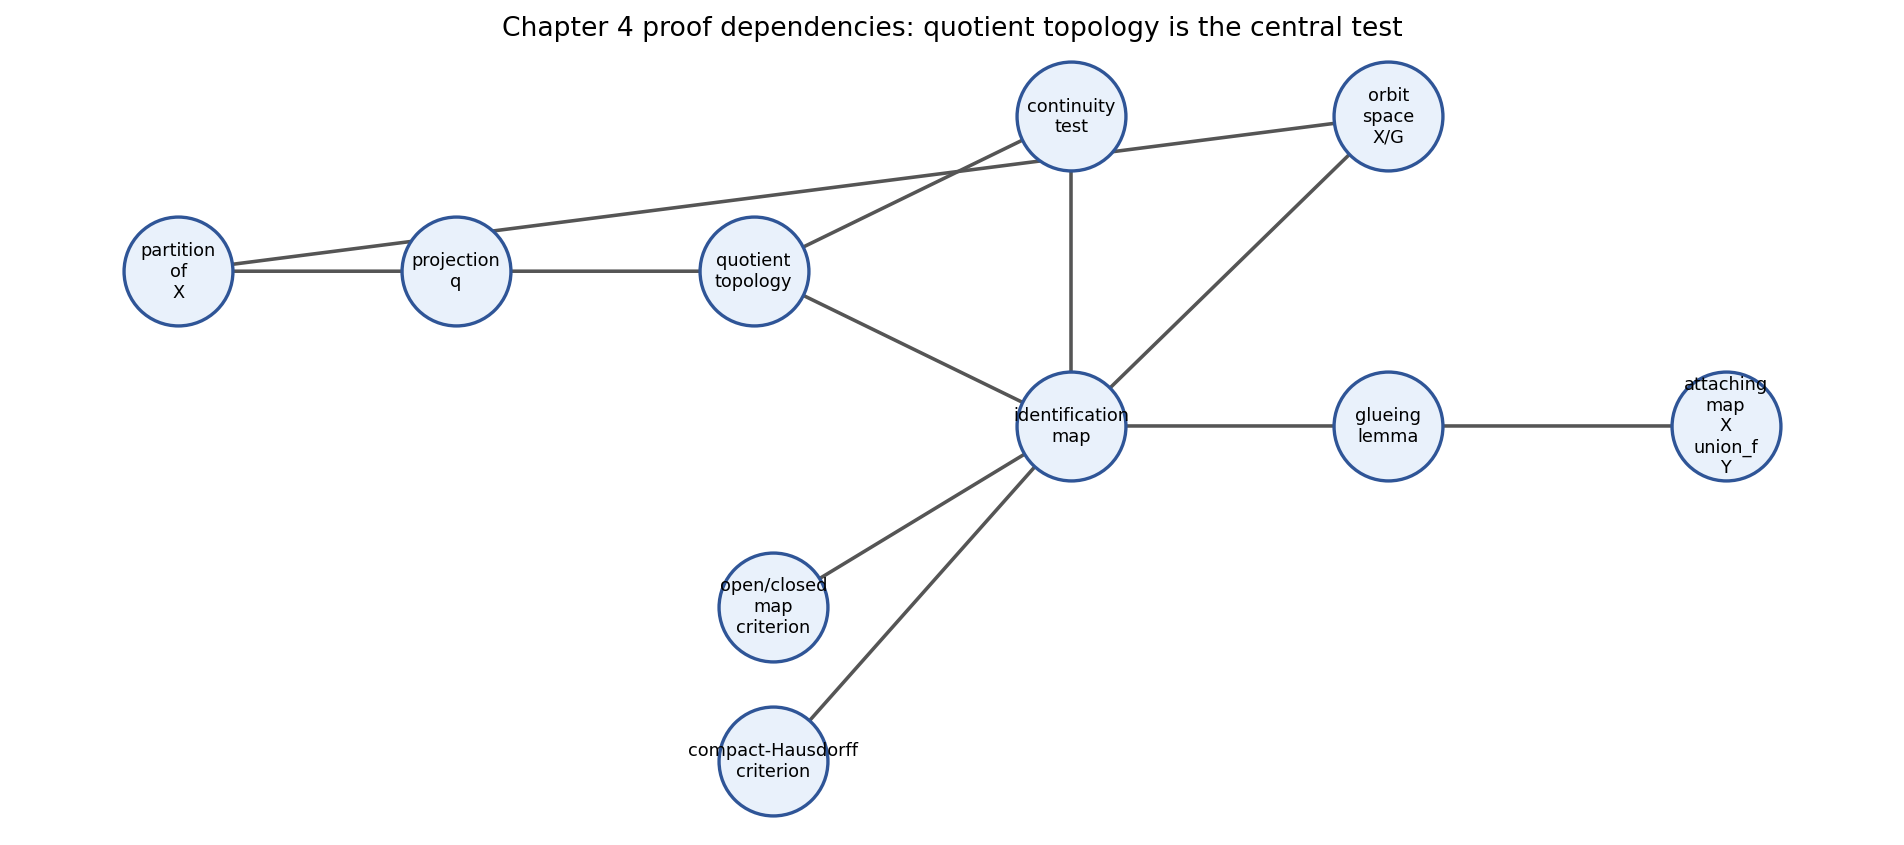

,concept,node_count,edge_count,is_directed_acyclic,topological_order_prefix,central_node_out_degree
0,proof dependency scaffold for identification s...,10,11,True,"[partition of X, open/closed map criterion, co...",2


In [5]:
G = nx.DiGraph()
proof_nodes = {
    "partition of X": "choose equivalence classes",
    "projection q": "send each point to its class",
    "quotient topology": "U open iff q^{-1}(U) open",
    "continuity test": "f continuous iff f q continuous",
    "identification map": "onto map with quotient topology",
    "open/closed map criterion": "open or closed onto maps identify",
    "compact-Hausdorff criterion": "compact source and Hausdorff target",
    "glueing lemma": "continuous pieces assemble",
    "attaching map X union_f Y": "build spaces by glueing subspaces",
    "orbit space X/G": "partition by group action",
}
G.add_nodes_from(proof_nodes)
G.add_edges_from([
    ("partition of X", "projection q"),
    ("projection q", "quotient topology"),
    ("quotient topology", "continuity test"),
    ("quotient topology", "identification map"),
    ("identification map", "continuity test"),
    ("open/closed map criterion", "identification map"),
    ("compact-Hausdorff criterion", "identification map"),
    ("identification map", "glueing lemma"),
    ("glueing lemma", "attaching map X union_f Y"),
    ("partition of X", "orbit space X/G"),
    ("identification map", "orbit space X/G"),
])

pos = {
    "partition of X": (0, 2),
    "projection q": (1.4, 2),
    "quotient topology": (2.9, 2),
    "continuity test": (4.5, 2.6),
    "identification map": (4.5, 1.4),
    "open/closed map criterion": (3.0, 0.7),
    "compact-Hausdorff criterion": (3.0, 0.1),
    "glueing lemma": (6.1, 1.4),
    "attaching map X union_f Y": (7.8, 1.4),
    "orbit space X/G": (6.1, 2.6),
}

fig, ax = plt.subplots(figsize=(12, 5.4))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.6, edge_color="#555555")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#e9f1fb", edgecolors="#2f5597", node_size=2400, linewidths=1.5)
labels = {node: node.replace(" ", "\n") for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8)
ax.set_title("Chapter 4 proof dependencies: quotient topology is the central test")
ax.axis("off")
fig.tight_layout()
proof_graph_path = register(save_matplotlib(fig, UNIT, "figures", "concept-dependency-map.png"))
plt.close(fig)

proof_checks = {
    "concept": "proof dependency scaffold for identification spaces",
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "is_directed_acyclic": nx.is_directed_acyclic_graph(G),
    "topological_order_prefix": list(nx.topological_sort(G))[:5],
    "central_node_out_degree": int(G.out_degree("quotient topology")),
}
proof_check_path = register(save_json(proof_checks, UNIT, "checks", "proof-scaffold-checks.json"))
check_registry.append(proof_check_path)

assert proof_checks["is_directed_acyclic"]
assert proof_checks["central_node_out_degree"] >= 2

display_artifact(proof_graph_path, width=780)
pd.DataFrame([proof_checks])

## Topological Groups And Quotient Groups

A topological group has enough compatibility between topology and algebra that left and right translations are homeomorphisms. That makes quotient examples especially rich. In `R/Z`, the map `x -> exp(2*pi*i*x)` identifies exactly the integer translates of `x`; it is also a group homomorphism from addition mod integers to multiplication on the circle.

Matrix groups supply the same pattern in higher dimensions. Orthogonal matrices preserve the unit sphere, so `O(n)` acts on `S^{n-1}`. The orbit map `A -> A e_1` identifies matrices with the same first column, giving the homogeneous-space model `O(n)/O(n-1)`.

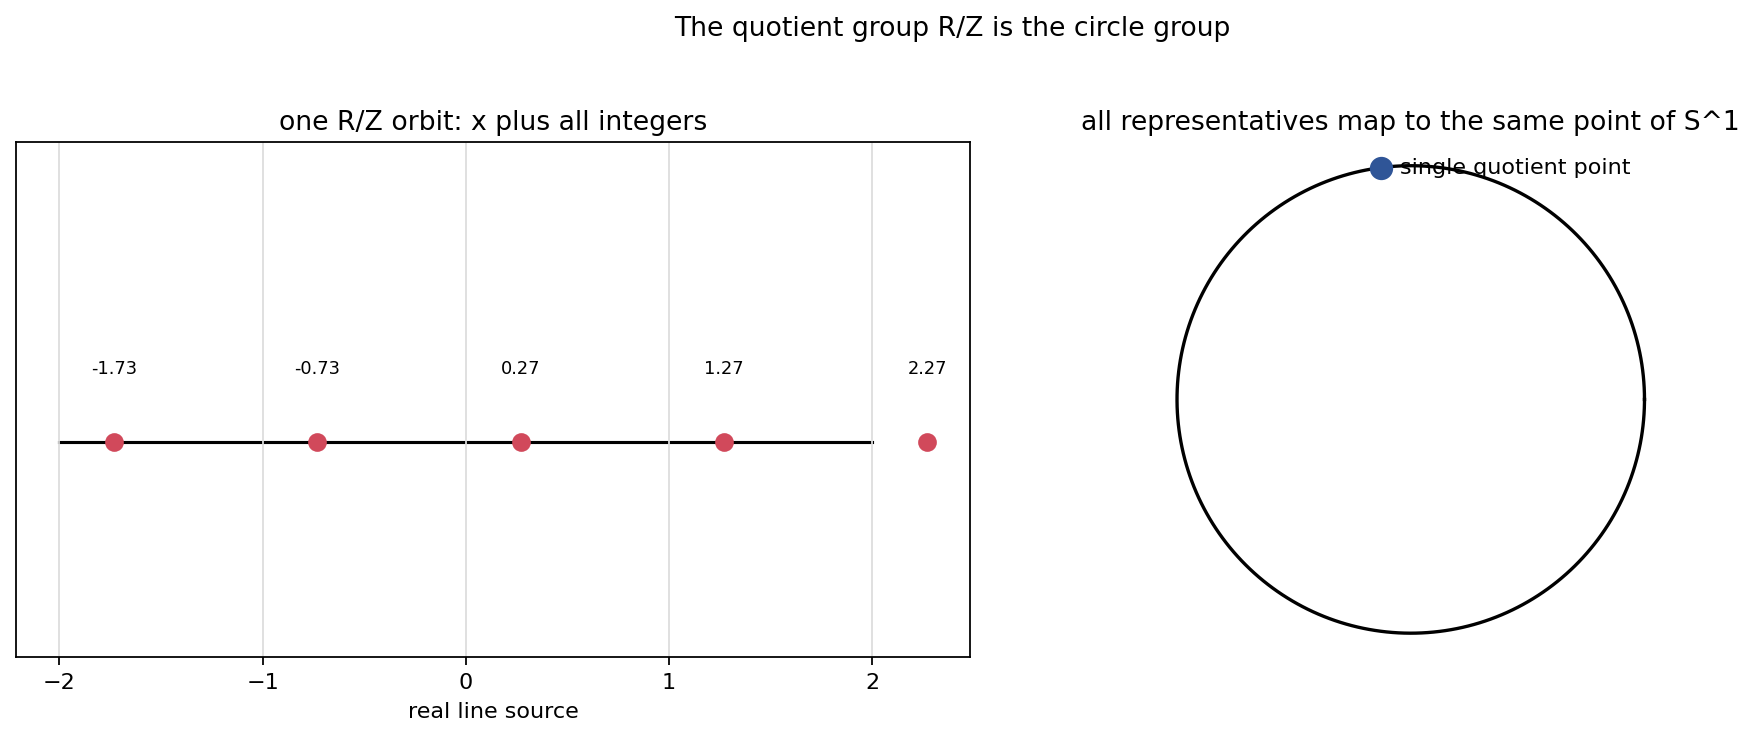

,concept,R_mod_Z_representative,integer_translate_max_error,circle_homomorphism_max_error,circle_inverse_max_error,SO2_determinant,random_O3_orthogonality_error,random_O3_first_column_norm
0,topological group quotient and orthogonal acti...,0.27,1.405430e-15,1.421779e-15,1.570092e-16,1.0,3.927337e-16,1.0


In [6]:
def circle_exp(x):
    x = np.asarray(x, dtype=float)
    return np.exp(2j * np.pi * x)


xs = np.linspace(-2.0, 2.0, 401)
representative = 0.27
orbit_points = representative + np.arange(-2, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(xs, np.zeros_like(xs), color="black", lw=1.4)
for n in range(-2, 3):
    ax.axvline(n, color="#dddddd", lw=0.8)
ax.scatter(orbit_points, np.zeros_like(orbit_points), color="#d1495b", s=55, zorder=5)
for point in orbit_points:
    ax.text(point, 0.08, f"{point:.2f}", ha="center", fontsize=8)
ax.set_ylim(-0.25, 0.35)
ax.set_yticks([])
ax.set_title("one R/Z orbit: x plus all integers")
ax.set_xlabel("real line source")

ax = axes[1]
theta = np.linspace(0, 2 * np.pi, 500)
ax.plot(np.cos(theta), np.sin(theta), color="black", lw=1.5)
z = circle_exp(orbit_points)
ax.scatter(z.real, z.imag, color="#d1495b", s=65, zorder=5)
ax.scatter([circle_exp(representative).real], [circle_exp(representative).imag], color="#2f5597", s=90, zorder=6)
ax.text(circle_exp(representative).real + 0.08, circle_exp(representative).imag, "single quotient point", va="center")
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("all representatives map to the same point of S^1")
fig.suptitle("The quotient group R/Z is the circle group", y=1.02)
fig.tight_layout()
rz_fig_path = register(save_matplotlib(fig, UNIT, "figures", "group-quotient-R-mod-Z.png"))
plt.close(fig)

rng = np.random.default_rng(202604)
a = rng.random(40)
b = rng.random(40)
hom_errors = np.abs(circle_exp(a + b) - circle_exp(a) * circle_exp(b))
inverse_errors = np.abs(circle_exp(-a) - 1 / circle_exp(a))

M = rng.normal(size=(3, 3))
Q, R = np.linalg.qr(M)
Q = Q @ np.diag(np.sign(np.diag(R)))
orthogonality_error = float(np.linalg.norm(Q.T @ Q - np.eye(3)))
first_column_norm = float(np.linalg.norm(Q[:, 0]))
so2_angle = 0.73
SO2 = np.array([[np.cos(so2_angle), -np.sin(so2_angle)], [np.sin(so2_angle), np.cos(so2_angle)]])

for n in range(-2, 3):
    assert abs(circle_exp(representative + n) - circle_exp(representative)) < 1e-12

group_checks = {
    "concept": "topological group quotient and orthogonal action checks",
    "R_mod_Z_representative": representative,
    "integer_translate_max_error": float(np.max(np.abs(circle_exp(orbit_points) - circle_exp(representative)))),
    "circle_homomorphism_max_error": float(np.max(hom_errors)),
    "circle_inverse_max_error": float(np.max(inverse_errors)),
    "SO2_determinant": float(np.linalg.det(SO2)),
    "random_O3_orthogonality_error": orthogonality_error,
    "random_O3_first_column_norm": first_column_norm,
}
group_check_path = register(save_json(group_checks, UNIT, "checks", "topological-group-checks.json"))
check_registry.append(group_check_path)

assert group_checks["integer_translate_max_error"] < 1e-12
assert group_checks["circle_homomorphism_max_error"] < 1e-12
assert abs(group_checks["SO2_determinant"] - 1.0) < 1e-12
assert orthogonality_error < 1e-12
assert abs(first_column_norm - 1.0) < 1e-12

display_artifact(rz_fig_path, width=760)
pd.DataFrame([group_checks])

## Orbit Spaces: Representatives Are A Convenience

For an action of a topological group `G` on a space `X`, the orbit space `X/G` identifies `x` with every `g(x)`. Representatives help us draw the quotient, but they are not part of the quotient data.

The source span gives several orbit-space examples: integer translations of the line give the circle, `Z^2` translations of the plane give the torus, antipodal action on a sphere gives projective space, and a real-line action on the torus with irrational slope gives dense proper orbits. The artifact below compares a rational slope, which closes up, with the irrational slope `sqrt(2)`, which keeps returning to new regions of the same fundamental square.

In [7]:
def torus_from_square(x, y, major=2.0, minor=0.55):
    theta = 2 * np.pi * np.asarray(x)
    phi = 2 * np.pi * np.asarray(y)
    X = (major + minor * np.cos(phi)) * np.cos(theta)
    Y = (major + minor * np.cos(phi)) * np.sin(theta)
    Z = minor * np.sin(phi)
    return X, Y, Z


def orbit_samples(alpha, T=42.0, count=1800):
    t = np.linspace(0, T, count)
    x = np.mod(t, 1.0)
    y = np.mod(alpha * t, 1.0)
    return t, x, y


def grid_coverage(alpha, T=90.0, count=6000, bins=24):
    _, x, y = orbit_samples(alpha, T=T, count=count)
    cells = set(zip(np.minimum((x * bins).astype(int), bins - 1), np.minimum((y * bins).astype(int), bins - 1)))
    return len(cells) / (bins * bins)


slope_data = [
    ("rational slope 3/2: closed orbit", 1.5, "#d1495b"),
    ("irrational slope sqrt(2): dense orbit sample", math.sqrt(2), "#2f5597"),
]

orbit_fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=["fundamental square for T^2", "same representatives on a torus model"],
    column_widths=[0.42, 0.58],
)

orbit_fig.add_trace(go.Scatter(x=[0, 1, 1, 0, 0], y=[0, 0, 1, 1, 0], mode="lines", line=dict(color="black"), name="square boundary", showlegend=False), row=1, col=1)
u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, 2 * np.pi, 40)
U, V = np.meshgrid(u, v)
Xs = (2.0 + 0.55 * np.cos(V)) * np.cos(U)
Ys = (2.0 + 0.55 * np.cos(V)) * np.sin(U)
Zs = 0.55 * np.sin(V)
orbit_fig.add_trace(go.Surface(x=Xs, y=Ys, z=Zs, opacity=0.28, colorscale="Greys", showscale=False, name="torus"), row=1, col=2)

for label, alpha, color in slope_data:
    _, x, y = orbit_samples(alpha)
    X, Y, Z = torus_from_square(x, y)
    visible = label.startswith("irrational")
    trace2d = go.Scattergl(x=x, y=y, mode="markers", marker=dict(size=3, color=color, opacity=0.62), name=label, visible=visible)
    trace3d = go.Scatter3d(x=X, y=Y, z=Z, mode="lines", line=dict(width=4, color=color), name=label + " on torus", visible=visible, showlegend=False)
    orbit_fig.add_trace(trace2d, row=1, col=1)
    orbit_fig.add_trace(trace3d, row=1, col=2)


def visibility_for(index):
    flags = [True, True]
    for j in range(len(slope_data)):
        flags.extend([j == index, j == index])
    return flags


buttons = []
for idx, (label, _, _) in enumerate(slope_data):
    buttons.append(dict(label=label, method="update", args=[{"visible": visibility_for(idx)}, {"title": "Orbit representatives under real-line actions on the torus"}]))

orbit_fig.update_layout(
    title="Orbit representatives under real-line actions on the torus",
    height=570,
    margin=dict(l=10, r=10, t=80, b=20),
    updatemenus=[dict(type="buttons", direction="down", buttons=buttons, x=0.02, y=1.13)],
)
orbit_fig.update_xaxes(range=[0, 1], constrain="domain", title_text="x mod 1", row=1, col=1)
orbit_fig.update_yaxes(range=[0, 1], scaleanchor="x", scaleratio=1, title_text="y mod 1", row=1, col=1)
orbit_fig.update_scenes(aspectmode="data", xaxis_visible=False, yaxis_visible=False, zaxis_visible=False, row=1, col=2)

orbit_html_path = register(strip_trailing_whitespace(save_plotly_html(orbit_fig, UNIT, "html", "rotation-orbit-representatives.html", include_plotlyjs=True)))

origin = np.array(torus_from_square(0, 0), dtype=float)
closed = np.array(torus_from_square(2, 3), dtype=float)
orbit_checks = {
    "concept": "orbit space representatives for torus flows",
    "rational_slope": 1.5,
    "irrational_slope": math.sqrt(2),
    "rational_grid_coverage_24x24": float(grid_coverage(1.5)),
    "irrational_grid_coverage_24x24": float(grid_coverage(math.sqrt(2))),
    "rational_closure_error_after_time_2": float(np.linalg.norm(origin - closed)),
    "sample_count_per_orbit": 1800,
}
orbit_check_path = register(save_json(orbit_checks, UNIT, "checks", "orbit-space-checks.json"))
check_registry.append(orbit_check_path)

assert orbit_checks["rational_closure_error_after_time_2"] < 1e-12
assert orbit_checks["irrational_grid_coverage_24x24"] > orbit_checks["rational_grid_coverage_24x24"]

display_artifact(orbit_html_path, width="100%", height=570)
pd.DataFrame([orbit_checks])

,concept,rational_slope,irrational_slope,rational_grid_coverage_24x24,irrational_grid_coverage_24x24,rational_closure_error_after_time_2,sample_count_per_orbit
0,orbit space representatives for torus flows,1.5,1.414214,0.166667,1.0,1.312888e-15,1800


## Quotient Invariants And Failure Modes

A quotient map is continuous and onto by construction, so compactness, connectedness, and path connectedness pass from the source to the quotient. Hausdorff separation does not automatically pass. The rational-coset quotient of the real line is the warning example: rational shifts are dense, so every nonempty saturated open set is forced to spread everywhere.

That is why we keep several independent checks around. A surface picture can be misleading, a representative can be arbitrary, and a quotient can destroy separation. Invariants such as Euler characteristic, boundary count, orientability, orbit closure behavior, and exact group identities give us independent ways to recognize the quotient.

## Applied Lab: Decode A Fundamental Region

Change `lab_model` to one of `"cylinder"`, `"Mobius strip"`, `"torus"`, or `"projective plane style disk"`, then rerun the next cell. Your job is to predict which invariant should change before you look at the output.

The lab is deliberately small: it does not try to classify every surface. It trains the quotient habit from this chapter: read the identification rule first, then ask which points, edges, or orbits have become indistinguishable.

In [8]:
lab_model = "Mobius strip"

lab_lookup = edge_df.set_index("model").to_dict(orient="index")
if lab_model not in lab_lookup:
    raise ValueError(f"Choose one of: {list(lab_lookup)}")

selected = lab_lookup[lab_model]
comparison = edge_df[["model", "boundary_components", "orientable", "euler_characteristic"]].copy()
comparison["selected"] = comparison["model"].eq(lab_model)

lab_result = {
    "selected_model": lab_model,
    "recipe": selected["recipe"],
    "prediction_prompt": "Changing the edge rule should change boundary count, orientability, Euler characteristic, or none of these.",
    "boundary_components": int(selected["boundary_components"]),
    "orientable": bool(selected["orientable"]),
    "euler_characteristic": int(selected["euler_characteristic"]),
    "local_seam_test": selected["local_seam_test"],
}
lab_path = register(save_json(lab_result, UNIT, "checks", "applied-lab-output.json"))
check_registry.append(lab_path)

assert lab_result["selected_model"] == lab_model
assert lab_result["boundary_components"] >= 0

comparison

,model,boundary_components,orientable,euler_characteristic,selected
0,cylinder,2,True,0,False
1,Mobius strip,1,False,0,True
2,torus,0,True,0,False
3,projective plane style disk,0,False,1,False


## Final Sanity Checks

The final cell checks the chapter claims that are concrete enough to validate: artifact existence, nonzero file size, endpoint identification, edge-model invariants, seam parameterization, group quotient identities, theorem-graph structure, and orbit sampling behavior.

In [9]:
required_artifacts = [
    quotient_fig,
    edge_gallery_path,
    surface_html_path,
    proof_graph_path,
    rz_fig_path,
    orbit_html_path,
    edge_table_path,
    *check_registry,
]

artifact_sizes = {}
for path in required_artifacts:
    resolved = assert_artifact(path, min_bytes=128)
    artifact_sizes[str(resolved.relative_to(BOOK_ROOT))] = resolved.stat().st_size

png_like = [quotient_fig, edge_gallery_path, proof_graph_path, rz_fig_path]
for path in png_like:
    assert_artifact(path, min_bytes=1024)
for path in [surface_html_path, orbit_html_path]:
    assert_artifact(path, min_bytes=4096)

assert quotient_checks["endpoint_identification_error"] < 1e-12
assert edge_checks["euler_characteristics"]["cylinder"] == 0
assert edge_checks["euler_characteristics"]["Mobius strip"] == 0
assert edge_checks["euler_characteristics"]["torus"] == 0
assert edge_checks["euler_characteristics"]["projective plane style disk"] == 1
assert not edge_df.loc[edge_df["model"].eq("Mobius strip"), "orientable"].item()
assert surface_checks["mobius_flipped_seam_max_error"] < 1e-12
assert group_checks["circle_homomorphism_max_error"] < 1e-12
assert proof_checks["is_directed_acyclic"]
assert orbit_checks["irrational_grid_coverage_24x24"] > orbit_checks["rational_grid_coverage_24x24"]

sanity_summary = {
    "unit": UNIT,
    "source_span": "Armstrong Basic Topology printed pp. 65-86; PDF pp. 76-97",
    "artifact_count_checked": len(required_artifacts),
    "png_static_artifacts": [str(Path(p).relative_to(BOOK_ROOT)) for p in png_like],
    "html_interactive_artifacts": [str(surface_html_path.relative_to(BOOK_ROOT)), str(orbit_html_path.relative_to(BOOK_ROOT))],
    "tables": [str(edge_table_path.relative_to(BOOK_ROOT))],
    "checks": [str(Path(p).relative_to(BOOK_ROOT)) for p in check_registry],
    "core_assertions": {
        "interval_endpoints_identified": True,
        "mobius_seam_requires_flip": True,
        "projective_plane_style_chi": 1,
        "R_mod_Z_homomorphism_verified": True,
        "irrational_orbit_sample_covers_more_grid_cells_than_rational_sample": True,
    },
    "artifact_sizes": artifact_sizes,
}
sanity_path = register(save_json(sanity_summary, UNIT, "checks", "sanity-checks.json"))
assert_artifact(sanity_path, min_bytes=512)

pd.json_normalize(sanity_summary)

,unit,source_span,artifact_count_checked,png_static_artifacts,html_interactive_artifacts,tables,checks,core_assertions.interval_endpoints_identified,core_assertions.mobius_seam_requires_flip,core_assertions.projective_plane_style_chi,...,artifact_sizes.artifacts\chapter-04\figures\group-quotient-R-mod-Z.png,artifact_sizes.artifacts\chapter-04\html\rotation-orbit-representatives.html,artifact_sizes.artifacts\chapter-04\tables\edge-model-invariants.csv,artifact_sizes.artifacts\chapter-04\checks\quotient-map-checks.json,artifact_sizes.artifacts\chapter-04\checks\edge-model-checks.json,artifact_sizes.artifacts\chapter-04\checks\surface-parameterization-checks.json,artifact_sizes.artifacts\chapter-04\checks\proof-scaffold-checks.json,artifact_sizes.artifacts\chapter-04\checks\topological-group-checks.json,artifact_sizes.artifacts\chapter-04\checks\orbit-space-checks.json,artifact_sizes.artifacts\chapter-04\checks\applied-lab-output.json
0,chapter-04,Armstrong Basic Topology printed pp. 65-86; PD...,14,[artifacts\chapter-04\figures\quotient-saturat...,[artifacts\chapter-04\html\edge-identification...,[artifacts\chapter-04\tables\edge-model-invari...,[artifacts\chapter-04\checks\quotient-map-chec...,True,True,1,...,58551,5225274,661,419,1635,413,357,424,332,425


## Takeaways

- A quotient space is controlled by a projection map; openness downstairs is checked by full preimages upstairs.
- Edge-pairing pictures are instructions, not proofs by themselves. The invariant table records what those instructions force.
- The compact-source/Hausdorff-target criterion is a practical way to recognize many concrete identification maps.
- Topological groups make quotient spaces systematic: translations, cosets, stabilizers, and orbit maps all organize the same construction.
- Orbit representatives are only a drawing device. The quotient remembers the orbit, not the chosen point used to display it.
- Hausdorffness is fragile under quotients, so quotient invariants and local-neighborhood checks should be used together.